# traitement 

          il est question ici de vérifier les données manquantes et les gérer 

In [11]:
# importation des bibliotheque

import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
df = pd.read_csv('beninwatch_clean.csv')

In [4]:
df.shape

(15188, 23)

In [5]:
df.describe()

,SQLDATE,YEAR,MonthYear,EventCode,EventBaseCode,EventRootCode,QuadClass,GoldsteinScale,NumMentions,NumSources,NumArticles,AvgTone,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long
count,1.518800e+04,15188.0,15188.000000,15188.000000,15188.000000,15188.000000,15188.000000,15188.000000,15188.000000,15188.000000,15188.000000,15188.000000,15188.000000,15188.000000,15188.000000
mean,2.025073e+07,2025.0,202507.176653,89.642744,68.667698,6.691467,1.751449,0.768409,6.214643,1.014222,6.091256,-1.324291,1.423163,9.371014,2.257125
std,3.911392e+02,0.0,3.920836,158.770951,53.972894,5.397691,1.118062,4.713676,4.336509,0.153304,4.037207,4.375577,1.070546,0.813790,0.217897
min,2.025010e+07,2025.0,202501.000000,10.000000,10.000000,1.000000,1.000000,-10.000000,1.000000,1.000000,1.000000,-18.518519,1.000000,6.280360,0.869667
25%,2.025040e+07,2025.0,202504.000000,40.000000,40.000000,4.000000,1.000000,-2.000000,2.000000,1.000000,2.000000,-4.311590,1.000000,9.500000,2.250000
50%,2.025072e+07,2025.0,202507.000000,50.000000,46.000000,4.000000,1.000000,1.900000,5.000000,1.000000,5.000000,-1.248439,1.000000,9.500000,2.250000
75%,2.025113e+07,2025.0,202511.000000,110.000000,100.000000,10.000000,3.000000,3.400000,10.000000,1.000000,10.000000,1.832994,1.000000,9.500000,2.250000
max,2.025123e+07,2025.0,202512.000000,1823.000000,195.000000,19.000000,4.000000,10.000000,48.000000,7.000000,48.000000,19.480519,5.000000,12.407400,3.694290


In [6]:
df.head()

,SQLDATE,YEAR,MonthYear,Actor1Name,Actor1Type1Code,Actor2Name,Actor2Type1Code,EventCode,EventBaseCode,EventRootCode,...,NumSources,NumArticles,AvgTone,ActionGeo_Type,ActionGeo_FullName,ActionGeo_CountryCode,ActionGeo_ADM1Code,ActionGeo_Lat,ActionGeo_Long,SOURCEURL
0,20250101,2025,202501,BENIN,NaN,NaN,NaN,51,51,5,...,1,5,-7.547170,1,Benin,BN,BN,9.5,2.25,https://dailypost.ng/2025/01/01/terrorism-alle...
1,20250101,2025,202501,BENIN,GOV,NaN,NaN,10,10,1,...,1,5,-8.482871,1,Benin,BN,BN,9.5,2.25,https://punchng.com/benin-republic-summons-nig...
2,20250101,2025,202501,DIPLOMAT,GOV,NaN,NaN,40,40,4,...,1,3,-7.843137,1,Benin,BN,BN,9.5,2.25,https://www.thecable.ng/benin-republic-summons...
3,20250101,2025,202501,GOVERNANCE,GOV,NaN,NaN,193,193,19,...,1,10,-0.812763,1,Benin,BN,BN,9.5,2.25,https://kaloumpresse.com/2019/05/27/nouvelle-c...
4,20250101,2025,202501,TANZANIA,NaN,NaN,NaN,128,128,12,...,1,10,-0.812763,1,Benin,BN,BN,9.5,2.25,https://kaloumpresse.com/2019/05/27/nouvelle-c...


In [12]:
#  Calcul du nombre et du pourcentage de valeurs manquantes par colonne
missing_data = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100


In [13]:
# Création d'un tableau récapitulatif
missing_df = pd.DataFrame({
    'Valeurs Manquantes': missing_data,
    'Pourcentage (%)': missing_percentage
}).sort_values(by='Pourcentage (%)', ascending=False)

print("--- Récapitulatif des valeurs manquantes ---")
print(missing_df[missing_df['Valeurs Manquantes'] > 0])


--- Récapitulatif des valeurs manquantes ---
                 Valeurs Manquantes  Pourcentage (%)
Actor2Type1Code               10731        70.654464
Actor1Type1Code                8696        57.255728
Actor2Name                     4602        30.300237
Actor1Name                     1522        10.021069


C:\Users\Roxanne\AppData\Local\Temp\ipykernel_9648\4115807200.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_df.index, y=missing_df['Pourcentage (%)'], palette='viridis')


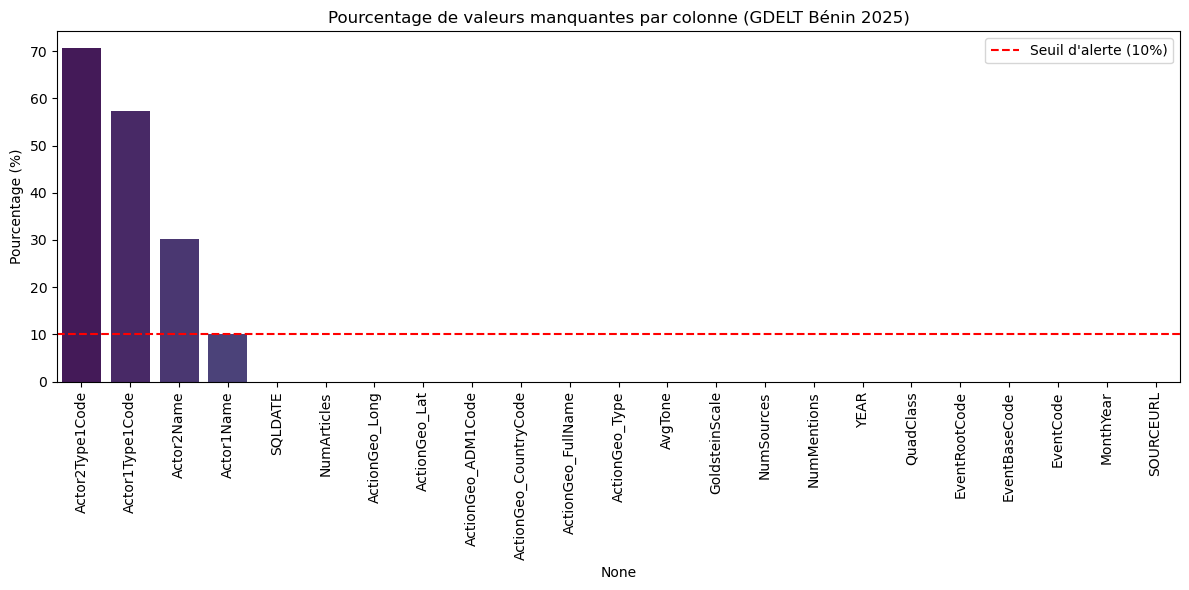

In [14]:
#  Visualisation graphique
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_df.index, y=missing_df['Pourcentage (%)'], palette='viridis')
plt.xticks(rotation=90)
plt.title('Pourcentage de valeurs manquantes par colonne (GDELT Bénin 2025)')
plt.ylabel('Pourcentage (%)')
plt.axhline(y=10, color='r', linestyle='--', label='Seuil d\'alerte (10%)')
plt.legend()
plt.tight_layout()
plt.show()


# gestion des valeurs manquantes 

    Actor2Type1Code — 70% manquant → Imputation par catégorie "UNKNOWN"

     Actor1Type1Code — 57% manquant → Imputation conditionnelle
   À 57%, on peut récupérer une grande partie des NaN en déduisant le type depuis Actor1Name.
       Les mots-clés sont adaptés aux acteurs réels de votre dataset. 

       Actor2Name — 30% manquant → Créer un flag puis imputer
À 30%, supprimer les lignes ferait perdre ~4 600 événements. On crée d'abord le flag avant tout fillna — sinon il vaudrait toujours 1.

Le flag has_actor2 devient une feature ML : un événement à deux acteurs nommés est structurellement différent d'un événement unidirectionnel.

Actor1Name — 10% manquant → Imputation simple
À seulement 10%, on garde toutes les lignes pour ne rien perdre pour le ML.

           Script complet  de néttoyage 

In [16]:

def clean_actors(df):
    df = df.copy()

    # 1. Flag has_actor2 — AVANT tout fillna
    df['has_actor2'] = df['Actor2Name'].notna().astype(int)

    # 2. Actor1Name — 10% manquant
    df['Actor1Name'] = df['Actor1Name'].fillna('Acteur non identifié')

    # 3. Actor2Name — 30% manquant
    df['Actor2Name'] = df['Actor2Name'].fillna('Non identifié')

    # 4. Actor1Type1Code — inférence depuis Actor1Name
    gov_kw = ['GOVERNMENT','MINISTRY','MINISTER','PRESIDENT','POLICE',
              'PREFET','BENIN','ECOWAS','AFRICA UNION','NIGER','TOGO']
    mil_kw = ['MILITARY','ARMY','FORCE','SOLDIER','ARMED','BATTALION']
    med_kw = ['MEDIA','PRESS','JOURNAL','NEWS','RADIO','TV']
    cvl_kw = ['CIVIL','NGO','ONG','ASSOCIATION','CITIZEN']

    def infer_type(name, code):
        if pd.notna(code): return code
        if pd.notna(name):
            n = str(name).upper()
            if any(k in n for k in gov_kw): return 'GOV'
            if any(k in n for k in mil_kw): return 'MIL'
            if any(k in n for k in med_kw): return 'MED'
            if any(k in n for k in cvl_kw): return 'CVL'
        return 'UNKNOWN'

    df['Actor1Type1Code'] = df.apply(
        lambda r: infer_type(r['Actor1Name'], r['Actor1Type1Code']), axis=1
    )

    # 5. Actor2Type1Code — 70% manquant, UNKNOWN direct
    df['Actor2Type1Code'] = df['Actor2Type1Code'].fillna('UNKNOWN')

    return df

df = clean_actors(df)

# Vérification après nettoyage 
print("\nAprès nettoyage :")
print(df[['Actor1Name','Actor2Name',
          'Actor1Type1Code','Actor2Type1Code',
          'has_actor2']].isnull().sum())
print(f"\nShape finale : {df.shape}")


Après nettoyage :
Actor1Name         0
Actor2Name         0
Actor1Type1Code    0
Actor2Type1Code    0
has_actor2         0
dtype: int64

Shape finale : (15188, 24)


In [17]:
df.to_csv('DANHOMÈ_INTEL_clean.csv', index=False, encoding='utf-8-sig')

In [19]:
import os
size = os.path.getsize('DANHOMÈ_INTEL_clean.csv') / (1024 * 1024)
print(f"Taille du fichier : {size:.2f} MB")

Taille du fichier : 3.22 MB


In [20]:
import pandas as pd

df = pd.read_csv('DANHOMÈ_INTEL_clean.csv')

In [21]:


def transform_data(df):
    df = df.copy()

    # 1. Renommage des colonnes
    rename_columns = {
        "SQLDATE":              "date",
        "YEAR":                 "year",
        "MonthYear":            "month_year",
        "Actor1Name":           "actor1_name",
        "Actor1Type1Code":      "actor1_type",
        "Actor2Name":           "actor2_name",
        "Actor2Type1Code":      "actor2_type",
        "EventCode":            "event_code",
        "EventBaseCode":        "event_base_code",
        "EventRootCode":        "event_root_code",
        "QuadClass":            "quad_class",
        "GoldsteinScale":       "goldstein_scale",
        "NumMentions":          "num_mentions",
        "NumSources":           "num_sources",
        "NumArticles":          "num_articles",
        "AvgTone":              "avg_tone",
        "ActionGeo_Type":       "geo_type",
        "ActionGeo_FullName":   "geo_full_name",
        "ActionGeo_CountryCode":"geo_country_code",
        "ActionGeo_ADM1Code":   "geo_adm1_code",
        "ActionGeo_Lat":        "latitude",
        "ActionGeo_Long":       "longitude",
        "SOURCEURL":            "source_url"
    }
    df = df.rename(columns=rename_columns)

    # 2. Conversion date — SQLDATE est un entier (ex: 20250101)
    df["date"] = pd.to_datetime(
        df["date"].astype(str),
        format="%Y%m%d",
        errors="coerce"
    )

    # 3. Ajout colonne mois lisible
    df["month_name"] = df["date"].dt.month_name()

    # 4. Suppression colonne month_year devenue redondante
    df.drop(columns=["month_year"], inplace=True)

    # 5. Suppression des doublons
    df = df.drop_duplicates()

    print("Nettoyage terminé ✓")
    print(f"Shape : {df.shape}")
    print(f"Types :\n{df[['date','month_name','year']].dtypes}")
    return df

df = transform_data(df)

Nettoyage terminé ✓
Shape : (14897, 24)
Types :
date          datetime64[ns]
month_name            object
year                   int64
dtype: object


In [22]:
print(df[['date', 'year', 'month_name']].head())

        date  year month_name
0 2025-01-01  2025    January
1 2025-01-01  2025    January
2 2025-01-01  2025    January
3 2025-01-01  2025    January
4 2025-01-01  2025    January


# CONTRÔLE FINAL — DANHOMÈ INTEL

In [23]:


# 1. Dimensions

print(f"\n DIMENSIONS")
print(f"   Lignes   : {df.shape[0]}")
print(f"   Colonnes : {df.shape[1]}")

# 2. Valeurs manquantes
print(f"\n  VALEURS MANQUANTES")
missing = df.isnull().sum()
if missing.sum() == 0:
    print(" Aucune valeur manquante")
else:
    print(missing[missing > 0])

# 3. Doublons
print(f"\n  DOUBLONS")
doublons = df.duplicated().sum()
if doublons == 0:
    print(" Aucun doublon")
else:
    print(f" {doublons} doublons détectés")

# 4. Vérification dates
print(f"\n DATES")
df["date"] = pd.to_datetime(df["date"], errors="coerce")
dates_invalides = df["date"].isnull().sum()
if dates_invalides == 0:
    print(f" Toutes les dates sont valides")
    print(f" Période : {df['date'].min().date()} → {df['date'].max().date()}")
else:
    print(f" {dates_invalides} dates invalides détectées")

# 5. Types des colonnes clés
print(f"\n TYPES DES COLONNES CLÉS")
cols_cles = ['date', 'year', 'month_name', 'goldstein_scale', 'avg_tone', 
             'num_articles', 'latitude', 'longitude']
for col in cols_cles:
    if col in df.columns:
        print(f"   {col:20s} : {df[col].dtype}")

# 6. Aperçu
print(f"\n APERÇU (5 premières lignes)")
print(df[['date', 'year', 'month_name', 'actor1_name', 
          'goldstein_scale', 'avg_tone']].head())



 DIMENSIONS
   Lignes   : 14897
   Colonnes : 24

  VALEURS MANQUANTES
 Aucune valeur manquante

  DOUBLONS
 Aucun doublon

 DATES
 Toutes les dates sont valides
 Période : 2025-01-01 → 2025-12-31

 TYPES DES COLONNES CLÉS
   date                 : datetime64[ns]
   year                 : int64
   month_name           : object
   goldstein_scale      : float64
   avg_tone             : float64
   num_articles         : int64
   latitude             : float64
   longitude            : float64

 APERÇU (5 premières lignes)
        date  year month_name actor1_name  goldstein_scale  avg_tone
0 2025-01-01  2025    January       BENIN              3.4 -7.547170
1 2025-01-01  2025    January       BENIN              0.0 -8.482871
2 2025-01-01  2025    January    DIPLOMAT              1.0 -7.843137
3 2025-01-01  2025    January  GOVERNANCE            -10.0 -0.812763
4 2025-01-01  2025    January    TANZANIA             -5.0 -0.812763


# FIN DU CONTRÔLE

In [24]:
df.to_csv('DANHOMÈ_INTEL_final_clean.csv', index=False, encoding='utf-8-sig')